# Act 0 — Math Foundations

The math you already know, made executable. Every function here reappears somewhere in Mara — softmax inside every attention head, cross-entropy as the training signal, KL divergence in alignment research, gradient descent as the engine that learns anything.

**Rules:** NumPy only until the PyTorch section. No `scipy.special.softmax`, no `torch.nn.functional.cross_entropy`. Implement from the formula. Verify against your pen-and-paper intuition.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sympy.solvers.diophantine.diophantine import prime_as_sum_of_two_squares

---
## 1 — Softmax

Given a vector of raw scores (logits), softmax produces a probability distribution:

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

**The numerical stability problem:** if any $x_i$ is large (say, 1000), $e^{1000}$ overflows to `inf`. The fix: subtract the maximum value before exponentiating. This doesn't change the output — verify that algebraically before coding it.

In [9]:
def softmax(x):
    """
    x: 1D numpy array of logits
    returns: probability distribution (same shape, sums to 1)
    """

    y = np.exp(x - np.max(x))
    return y / np.sum(y)

# Tests
out = softmax(np.array([1.0, 2.0, 3.0]))
assert out.shape == (3,)
assert abs(out.sum() - 1.0) < 1e-6
assert out[2] > out[1] > out[0]          # higher logit → higher probability

# Numerical stability: should not produce inf or nan
assert not np.any(np.isnan(softmax(np.array([1000.0, 1001.0, 1002.0]))))

# Uniform input → uniform output
uniform = softmax(np.array([0.0, 0.0, 0.0]))
assert np.allclose(uniform, [1/3, 1/3, 1/3])
print("1 — softmax passed")

1 — softmax passed


---
## 2 — Cross-Entropy Loss

Cross-entropy measures how well a predicted distribution $q$ matches a true distribution $p$:

$$H(p, q) = -\sum_i p_i \log q_i$$

In classification, $p$ is a one-hot vector (the correct class gets 1, everything else 0), so the sum collapses to a single term: $-\log q_{\text{correct}}$.

**What does the number mean?** If your model assigns probability 1.0 to the correct class, loss = 0. If it assigns probability close to 0, loss → ∞. The loss is a measure of surprise.

In [13]:
def cross_entropy(probs, target_idx):
    """
    probs: 1D numpy array, a probability distribution (sums to 1)
    target_idx: int, index of the correct class
    returns: scalar loss
    """

    return -np.log(np.clip(probs[target_idx], 1e-9, 1.0))

# Tests
perfect = np.array([0.0, 1.0, 0.0])     # model is certain, correct
assert cross_entropy(perfect, 1) < 1e-6  # near-zero loss

wrong = np.array([1.0, 0.0, 0.0])        # model is certain, wrong
assert cross_entropy(wrong, 1) > 10      # very high loss

uniform = np.array([1/3, 1/3, 1/3])
assert abs(cross_entropy(uniform, 0) - np.log(3)) < 1e-6
print("2 — cross-entropy passed")

2 — cross-entropy passed


---
## 3 — Entropy

Entropy measures the average surprise (uncertainty) in a distribution:

$$H(p) = -\sum_i p_i \log p_i$$

A uniform distribution has maximum entropy — every outcome is equally surprising. A peaked distribution (one outcome near 1) has near-zero entropy. In sampling, this is why low temperature → low entropy → more predictable Mara.

In [16]:
def entropy(p):
    """
    p: 1D numpy array, a probability distribution
    returns: scalar entropy (nats)
    Careful: 0 * log(0) should be treated as 0 (use np.where or clip)
    """

    return -np.sum(p*np.log(np.clip(p, 1e-9, 1.0)))

# Tests
uniform = np.array([0.5, 0.5])
assert abs(entropy(uniform) - np.log(2)) < 1e-6   # maximum entropy for 2 outcomes

certain = np.array([1.0, 0.0])
assert abs(entropy(certain)) < 1e-6               # zero entropy

# More uniform = higher entropy
peaked = np.array([0.9, 0.1])
assert entropy(uniform) > entropy(peaked)
print("3 — entropy passed")

3 — entropy passed


---
## 4 — KL Divergence

KL divergence measures how much distribution $q$ diverges from reference distribution $p$:

$$D_{KL}(p \| q) = \sum_i p_i \log \frac{p_i}{q_i}$$

Note: $D_{KL}(p \| q) \neq D_{KL}(q \| p)$ — it is not symmetric. When $p = q$, divergence is 0. This appears constantly in alignment research: RLHF penalises the fine-tuned model for diverging too far from the base model using KL.

In [17]:
def kl_divergence(p, q):
    """
    p: 1D numpy array, reference distribution
    q: 1D numpy array, approximating distribution
    returns: scalar KL divergence D_KL(p || q)
    Careful: skip terms where p_i = 0 (0 * log(0/q) = 0 by convention)
    """
    divergence = 0

    for i in range(len(p)):
        if p[i] == 0:
            continue
        divergence += p[i] * np.log(p[i] / q[i])

    return divergence

# Tests
p = np.array([0.1, 0.9])
assert abs(kl_divergence(p, p)) < 1e-6        # identical distributions → 0
assert kl_divergence(p, p[::-1]) > 0           # different → positive

# Asymmetry
q = np.array([0.6, 0.4])
assert abs(kl_divergence(p, q) - kl_divergence(q, p)) > 1e-6

# Zero in p is handled cleanly (no nan)
p2 = np.array([1.0, 0.0])
q2 = np.array([0.5, 0.5])
assert not np.isnan(kl_divergence(p2, q2))
print("4 — KL divergence passed")

4 — KL divergence passed


---
## 5 — Categorical Sampling

Given a probability distribution, draw a sample — an index — proportional to those probabilities. This is how Mara picks the next token: softmax over logits → probability distribution → sample.

Implement it using the inverse CDF method (cumulative sum + uniform draw), without using `np.random.choice`.

In [24]:
def categorical_sample(probs, rng=None):
    """
    probs: 1D numpy array, a probability distribution
    rng: optional numpy random Generator for reproducibility
    returns: int, sampled index
    Implement via cumulative sum + uniform draw. No np.random.choice.
    """

    cum_probs = np.cumsum(probs)

    sample = rng.uniform(0, 1)

    for i in range(len(probs)):
        if cum_probs[i] > sample:
            return i
    return None


# Tests
rng = np.random.default_rng(42)

# Certain distribution always returns the certain index
certain = np.array([0.0, 1.0, 0.0])
assert all(categorical_sample(certain, rng) == 1 for _ in range(10))

# Frequency test over many samples
p = np.array([0.1, 0.7, 0.2])
samples = [categorical_sample(p, rng) for _ in range(5000)]
counts = np.bincount(samples, minlength=3) / 5000
assert abs(counts[1] - 0.7) < 0.03    # index 1 should be drawn ~70% of the time
print("5 — categorical sampling passed")

5 — categorical sampling passed


---
## 6 — Bayes' Theorem

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

Prior belief + new evidence → updated belief. The denominator $P(B)$ is the normalisation constant — it ensures the result is a valid probability. Implement it directly from the formula.

In [22]:
def bayes(prior, likelihood, evidence):
    """
    prior:      P(A)       — belief before seeing data
    likelihood: P(B | A)   — probability of data given hypothesis
    evidence:   P(B)       — total probability of data
    returns:    P(A | B)   — updated belief
    """

    return (prior * likelihood) / evidence

# Tests
# Classic disease test: 1% prevalence, 99% sensitivity, 5% false positive rate
# P(disease) = 0.01, P(positive|disease) = 0.99
# P(positive) = P(pos|disease)*P(disease) + P(pos|healthy)*P(healthy)
p_disease = 0.01
p_pos_given_disease = 0.99
p_pos_given_healthy = 0.05
p_positive = p_pos_given_disease * p_disease + p_pos_given_healthy * (1 - p_disease)
posterior = bayes(p_disease, p_pos_given_disease, p_positive)
assert abs(posterior - 0.1667) < 1e-3   # ~16.7% — intuition check: still low!

# If likelihood equals evidence, posterior equals prior
assert abs(bayes(0.3, 0.5, 0.5) - 0.3) < 1e-9
print("6 — Bayes passed")

6 — Bayes passed


---
## 7 — Numerical Differentiation

The derivative of $f$ at $x$ is approximated by the finite difference:

$$f'(x) \approx \frac{f(x + h) - f(x - h)}{2h}$$

The centred version (used here) is more accurate than the one-sided version. This is how you verify gradients — compute them analytically, then check against the numerical estimate.

In [23]:
def numerical_gradient(f, x, h=1e-5):
    """
    f: scalar function of a scalar
    x: float, point at which to estimate gradient
    h: float, step size
    returns: float, estimated derivative
    """

    return (f(x+h) - f(x-h)) / (h * 2)


# Tests
# f(x) = x^2, f'(x) = 2x
f = lambda x: x ** 2
assert abs(numerical_gradient(f, 3.0) - 6.0) < 1e-4
assert abs(numerical_gradient(f, 0.0) - 0.0) < 1e-4

# f(x) = sin(x), f'(x) = cos(x)
assert abs(numerical_gradient(np.sin, np.pi/4) - np.cos(np.pi/4)) < 1e-4
print("7 — numerical gradient passed")

7 — numerical gradient passed


## 8 — Chain Rule
---

For a composition $h(x) = f(g(x))$:

$$h'(x) = f'(g(x)) \cdot g'(x)$$

This is the backbone of backpropagation. Every gradient flowing backward through a deep network is a product of chain rule applications. Compute it both analytically and verify against numerical gradient.

In [25]:
# h(x) = sin(x^2)
# g(x) = x^2,   g'(x) = 2x
# f(u) = sin(u), f'(u) = cos(u)
# h'(x) = cos(x^2) * 2x

def h(x):
    return np.sin(x ** 2)

def h_analytical_grad(x):
    """
    Analytical derivative of h(x) = sin(x^2) via chain rule.
    """

    return (np.cos(x**2) * (x*2))

# Tests: analytical and numerical should agree
for x in [0.5, 1.0, 2.0, -1.5]:
    analytical = h_analytical_grad(x)
    numerical = numerical_gradient(h, x)
    assert abs(analytical - numerical) < 1e-4, f"mismatch at x={x}"
print("8 — chain rule passed")

8 — chain rule passed


---
## 9 — Gradient Descent

The update rule:

$$\theta \leftarrow \theta - \alpha \nabla_\theta L(\theta)$$

where $\alpha$ is the learning rate and $\nabla_\theta L$ is the gradient of the loss with respect to the parameters. Implement one full training loop — starting from a bad parameter, descending to the minimum.

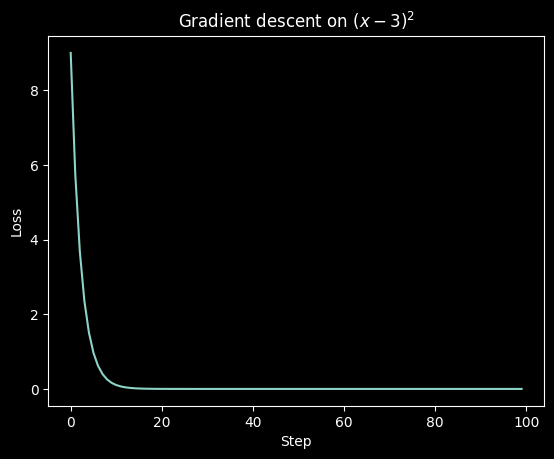

9 — gradient descent passed


In [29]:
def gradient_descent(f, grad_f, x_init, lr=0.1, steps=100):
    """
    f:      loss function, scalar → scalar
    grad_f: gradient function, scalar → scalar
    x_init: float, starting point
    lr:     float, learning rate
    steps:  int, number of update steps
    returns: (x_final, loss_history) where loss_history is a list of f(x) per step
    """

    x = x_init
    loss_history = []

    for step in range(steps):
        loss_history.append(f(x))
        x = x - lr * grad_f(x)

    return x, loss_history

# f(x) = (x - 3)^2, minimum at x = 3
f = lambda x: (x - 3) ** 2
grad_f = lambda x: 2 * (x - 3)

x_final, history = gradient_descent(f, grad_f, x_init=0.0, lr=0.1, steps=100)
assert abs(x_final - 3.0) < 1e-3        # converged to minimum
assert history[0] > history[-1]          # loss decreased
assert len(history) == 100

# Plot the loss curve
plt.plot(history)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Gradient descent on $(x-3)^2$")
plt.show()
print("9 — gradient descent passed")

---
## 10 — PyTorch Autograd

Everything above, you computed by hand. PyTorch's autograd does it automatically by building a computation graph as you run forward operations, then calling `.backward()` to propagate gradients.

The key: `requires_grad=True` tells PyTorch to track a tensor. After `.backward()`, the gradient is in `.grad`. Verify that autograd gives the same answer as your numerical gradient and analytical chain rule.

In [30]:
import torch

# --- 10.1: basic autograd ---
# f(x) = x^2 + 3x + 2, f'(x) = 2x + 3
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x + 2
y.backward()

assert abs(x.grad.item() - 7.0) < 1e-5   # f'(2) = 2*2 + 3 = 7
print("10.1 — basic autograd passed")

# --- 10.2: autograd through a chain ---
# h(x) = sin(x^2), same as section 8
x = torch.tensor(1.5, requires_grad=True)
y = torch.sin(x**2)
y.backward()

autograd_grad = x.grad.item()
analytical = h_analytical_grad(1.5)
assert abs(autograd_grad - analytical) < 1e-5
print("10.2 — autograd matches chain rule passed")

# --- 10.3: gradient descent in PyTorch ---
# Redo section 9 using autograd instead of grad_f
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1
history_torch = []

for _ in range(100):
    loss = (x - 3)**2
    history_torch.append(loss.item())
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
    x.grad.zero_()

assert abs(x.item() - 3.0) < 1e-3
print("10.3 — PyTorch gradient descent passed")
print("\nAll sections complete.")

10.1 — basic autograd passed
10.2 — autograd matches chain rule passed
10.3 — PyTorch gradient descent passed

All sections complete.
